In [3]:
# Install necessary libraries
!pip install -q transformers[torch] datasets accelerate scikit-learn

import torch
from transformers import BertForSequenceClassification, XLMRobertaTokenizer, Trainer, TrainingArguments
from datasets import load_dataset
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [1]:
import pandas as pd

# 1. Load the dataset (replace with your actual file name)
df = pd.read_csv('dataset.csv')

# 2. Define the label mapping
label_map = {
    "Appreciation": 0,
    "Question": 1,
    "Complaint": 2,
    "Spam": 3
}

# 3. Filter for only the classes we want (just in case there's extra noise)
df = df[df['intent_label'].isin(label_map.keys())]

# 4. Convert string labels to integers
df['label'] = df['intent_label'].map(label_map)

# 5. Take the first 50k rows
# Recommendation: Use stratified sampling to keep class proportions balanced
if len(df) > 50000:
    df = df.groupby('intent_label', group_keys=False).apply(lambda x: x.sample(frac=50000/len(df), random_state=42))
else:
    print(f"Dataset only has {len(df)} rows, using all of them.")

# 6. Keep only necessary columns for the model
df = df[['CommentText', 'label']].rename(columns={'CommentText': 'text'})

# 7. Final check
print(df['label'].value_counts())
df.head()

label
0    21508
2    17980
1    10380
3      134
Name: count, dtype: int64


/tmp/ipykernel_3051/2305626744.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('intent_label', group_keys=False).apply(lambda x: x.sample(frac=50000/len(df), random_state=42))


,text,label
89135,"Once again, disco gets overlooked.",0
95655,I thought the DMT was supposed to enlighten hi...,0
17256,This almost made me cry. Definitely a tear jer...,0
98984,I was looking for one of these the other day. ...,0
88358,That didn’t even look hard,0


In [ ]:
model_checkpoint = "microsoft/Multilingual-MiniLM-L12-H384"
# Remember: We must use XLMRobertaTokenizer for this specific checkpoint
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

def model_init():
    return BertForSequenceClassification.from_pretrained(model_checkpoint, num_labels=4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
from datasets import Dataset

# Convert Pandas DataFrame to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(df)

# Split into train and test (80/20)
hf_dataset = hf_dataset.train_test_split(test_size=0.2)

def tokenize_function(examples):
    # Use the tokenizer we defined in the previous step
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/40001 [00:00<?, ? examples/s]

Map:   0%|          | 0/10001 [00:00<?, ? examples/s]

In [8]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

training_args = TrainingArguments(
    output_dir="./minilm-yt-intent",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=True, # Critical for speed on T4 GPU
    report_to="none"
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

config.json:   0%|          | 0.00/430 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/Multilingual-MiniLM-L12-H384
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6255, training_loss=0.4640229259463523, metrics={'train_runtime': 1013.0998, 'train_samples_per_second': 197.419, 'train_steps_per_second': 6.174, 'total_flos': 3293837121469440.0, 'train_loss': 0.4640229259463523, 'epoch': 5.0})

label_map = {
    "Appreciation": 0,
    "Question": 1,
    "Complaint": 2,
    "Spam": 3
}

In [11]:
def predict_intent(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to("cuda")
    with torch.no_grad():
        logits = trainer.model(**inputs).logits
    predicted_class = logits.argmax(-1).item()
    return predicted_class

# Example
print(f"Intent Class: {predict_intent('check my channel')}")

Intent Class: 0


In [12]:
import torch
import numpy as np

# 1. Define the test set (Appreciation, Question, Complaint, Spam)
test_comments = [
    "This helped me so much, thank you!", "Best tutorial on the internet.", "Love from India! 🇮🇳", "Absolute legend, keep it up.", "Amazing quality as always.", "You saved my semester!", "GOAT status 🐐", "Simple and clear, thanks.", "Finally someone explains it right.", "Fire video 🔥🔥🔥",
    "How do I install the dependencies?", "Can you explain the part at 5:21 again?", "Does this work on Windows 11?", "Where can I find the source code?", "Will you make a video on React?", "Is there a Discord for this community?", "What is the time complexity of this?", "Can we use this for commercial projects?", "How to solve the OOM error?", "What's the song name in the intro?",
    "The audio quality is terrible.", "This code doesn't even run.", "You talk too fast, I can't follow.", "Waste of time, don't watch.", "The links in the description are broken.", "This is just a copy of another video.", "I tried this and it crashed my PC.", "Why is this video 20 minutes longer than it needs to be?", "Still waiting for a response to my last comment...", "Too many ads in this video.",
    "GET FREE BITCOIN NOW -> [LINK]", "Check out my channel for better content!", "I made $5000 working from home, ask me how!", "Click here to win a new iPhone 15!!", "PLEASE SUBSCRIBE TO ME I AM A SMALL CREATOR", "Follow me on IG for more @scammer_acc", "Watch my latest vlog guys!", "CHEAP SERVICES AVAILABLE HERE", "Win a giveaway by clicking the link in bio", "Sub4Sub anyone? Reply here."
]

# 2. Map labels back for readability
inv_label_map = {0: "Appreciation", 1: "Question", 2: "Complaint", 3: "Spam"}

# 3. Prediction Function
def batch_predict(texts):
    # Prepare inputs
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to("cuda")

    # Get predictions
    trainer.model.eval()
    with torch.no_grad():
        outputs = trainer.model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        labels = torch.argmax(predictions, dim=-1).cpu().numpy()
        confidences = torch.max(predictions, dim=-1).values.cpu().numpy()

    return labels, confidences

# 4. Execute and Display
labels, confs = batch_predict(test_comments)

print(f"{'Comment (First 40 chars)':<45} | {'Predicted Intent':<15} | {'Conf.'}")
print("-" * 75)
for text, label, conf in zip(test_comments, labels, confs):
    short_text = (text[:42] + '..') if len(text) > 42 else text
    print(f"{short_text:<45} | {inv_label_map[label]:<15} | {conf:.2%}")

Comment (First 40 chars)                      | Predicted Intent | Conf.
---------------------------------------------------------------------------
This helped me so much, thank you!            | Appreciation    | 98.82%
Best tutorial on the internet.                | Question        | 80.46%
Love from India! 🇮🇳                           | Appreciation    | 98.79%
Absolute legend, keep it up.                  | Appreciation    | 97.82%
Amazing quality as always.                    | Appreciation    | 98.62%
You saved my semester!                        | Appreciation    | 98.68%
GOAT status 🐐                                 | Complaint       | 73.50%
Simple and clear, thanks.                     | Appreciation    | 98.75%
Finally someone explains it right.            | Question        | 52.06%
Fire video 🔥🔥🔥                                | Appreciation    | 76.85%
How do I install the dependencies?            | Question        | 96.27%
Can you explain the part at 5:21 again?       | 

Re Training again with 3 labels

In [16]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import BertForSequenceClassification, XLMRobertaTokenizer, Trainer, TrainingArguments, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# 1. Load the dataset (replace with your actual file name)
df = pd.read_csv('dataset.csv')

# 1. PREPROCESS DATA (Filter & Map)
# Assuming 'df' is your original dataframe with 'CommentText' and 'intent_label'
label_map = {"Appreciation": 0, "Question": 1, "Complaint": 2}

# Remove Spam and only keep the three target classes
df_filtered = df[df['intent_label'] != 'Spam'].copy()
df_filtered = df_filtered[df_filtered['intent_label'].isin(label_map.keys())]
df_filtered['label'] = df_filtered['intent_label'].map(label_map)

# Use stratified sampling for 50k rows
if len(df_filtered) > 50000:
    df_3class = df_filtered.groupby('label', group_keys=False).apply(lambda x: x.sample(frac=50000/len(df_filtered), random_state=42))
else:
    df_3class = df_filtered

# 2. CONVERT TO HUGGINGFACE FORMAT
hf_dataset = Dataset.from_pandas(df_3class[['CommentText', 'label']].rename(columns={'CommentText': 'text'}))
hf_dataset = hf_dataset.train_test_split(test_size=0.2)

# 3. TOKENIZATION
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_fn, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4. INITIALIZE 3-CLASS MODEL
model = BertForSequenceClassification.from_pretrained(
    "microsoft/Multilingual-MiniLM-L12-H384",
    num_labels=3,
    ignore_mismatched_sizes=True # Clears the old 4-class head if you're re-running
)

# 5. TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./minilm-yt-3class",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,  # Slightly lower for more stability
    per_device_train_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    fp16=True,           # Keep this for T4 GPU speed
    load_best_model_at_end=True,
    report_to="none"
)

# 6. METRICS & TRAINER
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 7. START TRAINING
trainer.train()

/tmp/ipykernel_3051/351647270.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_3class = df_filtered.groupby('label', group_keys=False).apply(lambda x: x.sample(frac=50000/len(df_filtered), random_state=42))


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/Multilingual-MiniLM-L12-H384
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6250, training_loss=0.460505234375, metrics={'train_runtime': 1293.7969, 'train_samples_per_second': 154.584, 'train_steps_per_second': 4.831, 'total_flos': 3293695641600000.0, 'train_loss': 0.460505234375, 'epoch': 5.0})

Overall Accuracy: 93.00%

Classification Report:
              precision    recall  f1-score   support

Appreciation       0.91      0.94      0.93        34
    Question       0.89      1.00      0.94        33
   Complaint       1.00      0.85      0.92        33

    accuracy                           0.93       100
   macro avg       0.94      0.93      0.93       100
weighted avg       0.94      0.93      0.93       100



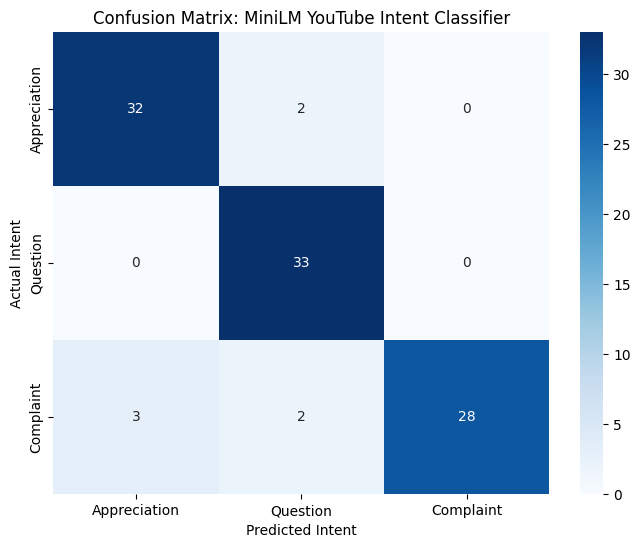

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. THE TEST DATASET (100 Comments with Ground Truth)
# Labels: 0=Appreciation, 1=Question, 2=Complaint
test_data = [
    # --- Appreciation (0) ---
    ("Amazing content as always!", 0), ("Best explanation I've found.", 0), ("You save my life with this.", 0),
    ("I love your teaching style.", 0), ("Keep up the good work!", 0), ("Mind-blowing tutorial.", 0),
    ("Clear and concise, thanks!", 0), ("This is gold.", 0), ("Legend status 👑", 0), ("Fire video! 🔥", 0),
    ("Love from India!", 0), ("Simple and effective.", 0), ("Subscribed immediately.", 0), ("So helpful!", 0),
    ("You're the GOAT.", 0), ("Big fan of your work.", 0), ("Brilliant analysis.", 0), ("Pure quality.", 0),
    ("Thoroughly enjoyed this.", 0), ("Great visuals.", 0), ("Exactly what I needed.", 0), ("Top notch.", 0),
    ("Helpful for my exams.", 0), ("Respect for the effort.", 0), ("Purely awesome.", 0), ("Thank you sir.", 0),
    ("You deserve millions of subs.", 0), ("Very insightful.", 0), ("Masterclass!", 0), ("Cool video.", 0),
    ("Informative and fun.", 0), ("Excellent job.", 0), ("Keep going!", 0), ("Learning a lot.", 0),
    # --- Questions (1) ---
    ("How do I install this?", 1), ("Where is the link?", 1), ("Can you explain line 45?", 1),
    ("Does this work on Mac?", 1), ("What is the time complexity?", 1), ("Is there a Part 2?", 1),
    ("Why use BERT over LSTM?", 1), ("How to fix the OOM error?", 1), ("Can we use it for free?", 1),
    ("What's the song in the intro?", 1), ("Are the links working?", 1), ("Where can I find the code?", 1),
    ("Is it compatible with Python 3.12?", 1), ("How to deploy this on AWS?", 1), ("Can you do a video on React?", 1),
    ("What is the prerequisite?", 1), ("How many epochs are needed?", 1), ("Is the dataset available?", 1),
    ("Can I use this for my thesis?", 1), ("What's your setup?", 1), ("How do I subscribe?", 1),
    ("When is the next upload?", 1), ("Which IDE are you using?", 1), ("Is there a Discord?", 1),
    ("How do you handle outliers?", 1), ("What is the learning rate?", 1), ("Can I contribute to the repo?", 1),
    ("How to contact you?", 1), ("Is this beginner friendly?", 1), ("Why did you choose PyTorch?", 1),
    ("What are the system requirements?", 1), ("How to increase accuracy?", 1), ("Can you show the results?", 1),
    # --- Complaints (2) ---
    ("This doesn't work.", 2), ("The audio is too low.", 2), ("Waste of time.", 2),
    ("You talk too fast.", 2), ("Code is full of bugs.", 2), ("Very confusing tutorial.", 2),
    ("The link is broken.", 2), ("Poor video quality.", 2), ("Stop making clickbait.", 2),
    ("It didn't help me.", 2), ("The logic is flawed.", 2), ("Hard to follow.", 2),
    ("Why is this 30 mins long?", 2), ("Not working on my PC.", 2), ("Instructions are unclear.", 2),
    ("This is a copy of another video.", 2), ("Too many ads.", 2), ("The font is too small.", 2),
    ("Disappointed with the content.", 2), ("Doesn't run on Colab.", 2), ("Outdated information.", 2),
    ("Not useful at all.", 2), ("You missed a step.", 2), ("The explanation is wrong.", 2),
    ("Waste of energy.", 2), ("Can't hear you clearly.", 2), ("Still no reply from you.", 2),
    ("This crashed my computer.", 2), ("Too much talking, no action.", 2), ("Unhelpful.", 2),
    ("Terrible quality.", 2), ("Very annoying intro.", 2), ("Not worth watching.", 2)
]

# Unzip comments and actual labels
comments, y_true = zip(*test_data)
label_names = ["Appreciation", "Question", "Complaint"]

# 2. RUN BATCH PREDICTION
def run_evaluation(texts):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to("cuda")
    trainer.model.eval()
    with torch.no_grad():
        outputs = trainer.model(**inputs)
        y_pred = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
    return y_pred

y_pred = run_evaluation(comments)

# 3. CALCULATE METRICS
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

# 4. PLOT CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Intent')
plt.ylabel('Actual Intent')
plt.title('Confusion Matrix: MiniLM YouTube Intent Classifier')
plt.show()

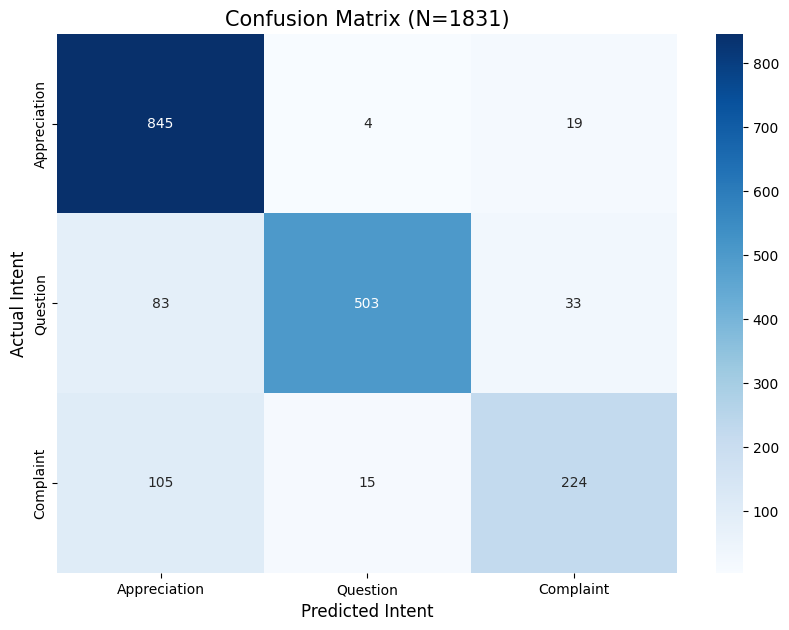

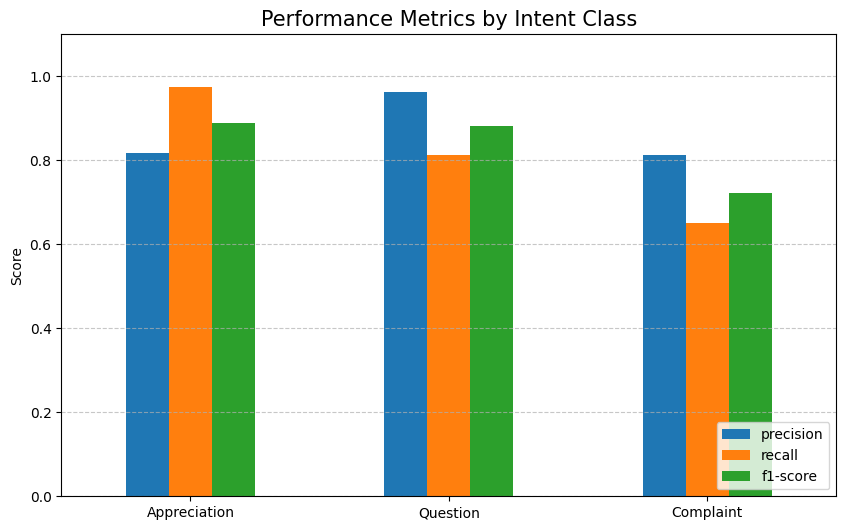


Overall Final Accuracy: 85.85%

DETAILED VALIDATION REPORT (NEW 2k DATASET)
              precision    recall  f1-score   support

Appreciation       0.82      0.97      0.89       868
    Question       0.96      0.81      0.88       619
   Complaint       0.81      0.65      0.72       344

    accuracy                           0.86      1831
   macro avg       0.86      0.81      0.83      1831
weighted avg       0.87      0.86      0.86      1831

Overall Final Accuracy: 85.85%


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. LOAD AND PREPROCESS 2k DATASET
# Replace 'new_dataset.csv' with your actual file name
df_new = pd.read_csv('new_dataset.csv')

# Take first 2k, remove Spam, map labels
df_test_2k = df_new.head(2000).copy()
df_test_2k = df_test_2k[df_test_2k['intent'] != 'Spam']
label_map = {"Appreciation": 0, "Question": 1, "Complaint": 2}
df_test_2k = df_test_2k[df_test_2k['intent'].isin(label_map.keys())]
df_test_2k['label'] = df_test_2k['intent'].map(label_map)

# 2. BATCH INFERENCE
texts = df_test_2k['comment'].tolist()
y_true = df_test_2k['label'].tolist()
y_pred = []

trainer.model.eval()
batch_size = 32
for i in range(0, len(texts), batch_size):
    batch = texts[i:i + batch_size]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = trainer.model(**inputs).logits
        y_pred.extend(torch.argmax(logits, dim=-1).cpu().numpy())

# 3. GENERATE PLOTS
target_names = ["Appreciation", "Question", "Complaint"]
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
cm = confusion_matrix(y_true, y_pred)

# --- Plot 1: Confusion Matrix ---
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix (N={len(df_test_2k)})', fontsize=15)
plt.xlabel('Predicted Intent', fontsize=12)
plt.ylabel('Actual Intent', fontsize=12)
plt.show()

# --- Plot 2: Class-wise Performance ---
metrics_df = pd.DataFrame(report).transpose().iloc[:3, :3] # Keep Precision, Recall, F1 for the 3 classes
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Performance Metrics by Intent Class', fontsize=15)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nOverall Final Accuracy: {accuracy_score(y_true, y_pred):.2%}")

# Print the textual metrics for review
print("\n" + "="*60)
print("DETAILED VALIDATION REPORT (NEW 2k DATASET)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names))
print(f"Overall Final Accuracy: {accuracy_score(y_true, y_pred):.2%}")
print("="*60)

In [20]:
import os

# Define your target path
save_path = '/content/drive/MyDrive/yt_models/minilm_intent_3class'

# Create the folder if it doesn't exist
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the model and tokenizer
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model successfully saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model successfully saved to: /content/drive/MyDrive/yt_models/minilm_intent_3class
